In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install pytorch-msssim -q

import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
GPU name: Tesla T4


In [3]:
#CELL A — Phantom Simulator (Cell 1-2 combine,

from __future__ import annotations
import numpy as np
import time
import matplotlib.pyplot as plt
from dataclasses import dataclass

@dataclass
class SimConfig:
    image_size: int = 256
    n_transducers: int = 128
    fs: float = 40e6
    c: float = 1540.0
    f0: float = 5e6
    bandwidth_frac: float = 0.6
    pitch: float = 0.3e-3
    depth_m: float = 0.05
    attenuation_db_cm_mhz: float = 0.5
    n_scatterers: int = 4000
    seed: int | None = None
    apply_tgc: bool = True

class PointScattererPhantom:
    def __init__(self, cfg):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        n = cfg.n_transducers
        self.elem_x = (np.arange(n) - (n - 1) / 2) * cfg.pitch
        self.lateral_extent = self.elem_x[-1] - self.elem_x[0]
        self.grid_x = np.linspace(self.elem_x[0], self.elem_x[-1], cfg.image_size)
        self.grid_z = np.linspace(1e-3, cfg.depth_m, cfg.image_size)
        self.Xg, self.Zg = np.meshgrid(self.grid_x, self.grid_z, indexing="xy")

    def _sample_scatterers(self):
        cfg = self.cfg
        x = self.rng.uniform(self.elem_x[0], self.elem_x[-1], cfg.n_scatterers)
        z = self.rng.uniform(self.grid_z[0], self.grid_z[-1], cfg.n_scatterers)
        amp = self.rng.rayleigh(scale=1.0, size=cfg.n_scatterers)
        n_lesions = self.rng.integers(1, 4)
        lesion_info = []
        for _ in range(n_lesions):
            cx = self.rng.uniform(self.elem_x[0] * 0.6, self.elem_x[-1] * 0.6)
            cz = self.rng.uniform(self.grid_z[0] + 5e-3, self.grid_z[-1] - 5e-3)
            r = self.rng.uniform(3e-3, 8e-3)
            inside = (x - cx) ** 2 + (z - cz) ** 2 <= r ** 2
            contrast = self.rng.choice([0.05, 3.0])
            amp[inside] *= contrast
            lesion_info.append({"cx": cx, "cz": cz, "r": r, "contrast": contrast})
        self.last_lesion_info = lesion_info
        return x, z, amp

    def required_time_samples(self, margin_factor=1.3):
        half_width = self.lateral_extent / 2
        max_range = np.sqrt(half_width ** 2 + self.cfg.depth_m ** 2)
        max_round_trip_time = 2 * max_range / self.cfg.c
        return int(np.ceil(max_round_trip_time * self.cfg.fs * margin_factor))

    def _synthesize_rf(self, x, z, amp, angle_rad, n_time_samples):
        cfg = self.cfg
        c, fs, f0 = cfg.c, cfg.fs, cfg.f0
        n_elem = cfg.n_transducers
        sigma_t = (cfg.bandwidth_frac * f0) ** -1 * 0.5
        t_tx = (x * np.sin(angle_rad) + z * np.cos(angle_rad)) / c
        ex = self.elem_x[:, None]
        r_rx = np.sqrt((x[None, :] - ex) ** 2 + z[None, :] ** 2)
        t_total = t_tx[None, :] + r_rx / c
        atten = (1.0 / np.maximum(r_rx, 1e-4)) * 10 ** (
            -cfg.attenuation_db_cm_mhz * (r_rx * 100) * (f0 / 1e6) / 20
        )
        weight = amp[None, :] * atten
        bin_idx = np.clip((t_total * fs).astype(np.int64), 0, n_time_samples - 1)
        elem_idx = np.repeat(np.arange(n_elem)[:, None], x.shape[0], axis=1)
        flat_idx = elem_idx.ravel() * n_time_samples + bin_idx.ravel()
        rf_flat = np.zeros(n_elem * n_time_samples, dtype=np.float32)
        np.add.at(rf_flat, flat_idx, weight.ravel().astype(np.float32))
        rf = rf_flat.reshape(n_elem, n_time_samples)
        pulse_t = np.arange(-3 * sigma_t, 3 * sigma_t, 1 / fs)
        pulse = np.exp(-0.5 * (pulse_t / sigma_t) ** 2) * np.cos(2 * np.pi * f0 * pulse_t)
        pulse = pulse.astype(np.float32)
        for e in range(n_elem):
            rf[e] = np.convolve(rf[e], pulse, mode="same")
        return rf

    def das_beamform(self, rf_by_angle, angles_rad):
        cfg = self.cfg
        n_time_samples = rf_by_angle.shape[-1]
        Xg, Zg = self.Xg, self.Zg
        H, W = Xg.shape
        n_elem = cfg.n_transducers
        compound = np.zeros_like(Xg, dtype=np.float32)
        for a_idx, angle in enumerate(angles_rad):
            t_tx = (Xg * np.sin(angle) + Zg * np.cos(angle)) / cfg.c
            ex = self.elem_x[:, None, None]
            r_rx = np.sqrt((Xg[None, :, :] - ex) ** 2 + Zg[None, :, :] ** 2)
            delay_samples = (t_tx[None, :, :] + r_rx / cfg.c) * cfg.fs
            idx = np.clip(delay_samples.astype(np.int64), 0, n_time_samples - 1)
            flat_idx = idx.reshape(n_elem, -1)
            gathered = np.take_along_axis(rf_by_angle[a_idx], flat_idx, axis=1)
            frame = gathered.reshape(n_elem, H, W).sum(axis=0)
            compound += frame
        if cfg.apply_tgc:
            depth_cm = Zg * 100
            tgc_gain_db = cfg.attenuation_db_cm_mhz * 2 * depth_cm * (cfg.f0 / 1e6)
            tgc_gain = 10 ** (tgc_gain_db / 20)
            compound = compound * tgc_gain
        envelope = np.abs(_hilbert_2d(compound))
        log_img = 20 * np.log10(envelope / (envelope.max() + 1e-8) + 1e-8)
        log_img = np.clip(log_img, -60, 0)
        return ((log_img + 60) / 60.0).astype(np.float32)

    def generate_pair(self, sparse_angles_deg, full_angles_deg, n_time_samples=None):
        if n_time_samples is None:
            n_time_samples = self.required_time_samples()
        x, z, amp = self._sample_scatterers()
        all_angles_deg = sorted(set(sparse_angles_deg) | set(full_angles_deg))
        rf_cache = {}
        for deg in all_angles_deg:
            rf_cache[deg] = self._synthesize_rf(x, z, amp, np.deg2rad(deg), n_time_samples)
        rf_sparse = np.stack([rf_cache[d] for d in sparse_angles_deg], axis=0)
        rf_full = np.stack([rf_cache[d] for d in full_angles_deg], axis=0)
        input_img = self.das_beamform(rf_sparse, np.deg2rad(sparse_angles_deg))
        target_img = self.das_beamform(rf_full, np.deg2rad(full_angles_deg))
        return input_img, target_img, rf_sparse

def _hilbert_2d(compound):
    from scipy.signal import hilbert
    return hilbert(compound, axis=0)

def make_angle_sets(n_sparse, n_full, max_deg=15.0):
    full = np.linspace(-max_deg, max_deg, n_full)
    idx = np.linspace(0, n_full - 1, n_sparse).astype(int)
    sparse = full[idx]
    return sparse.tolist(), full.tolist()

print("CELL A ready")

CELL A ready


In [4]:
# CELL B — Dataset + Pool Generation

import torch
from torch.utils.data import Dataset, DataLoader

def pregenerate_pool(base_cfg, n_phantoms, sparse_angles, full_angles, max_deg, seed_offset, save_path):
    sparse_deg, full_deg = make_angle_sets(sparse_angles, full_angles, max_deg)
    inputs = np.zeros((n_phantoms, base_cfg.image_size, base_cfg.image_size), dtype=np.float32)
    targets = np.zeros((n_phantoms, base_cfg.image_size, base_cfg.image_size), dtype=np.float32)
    t0 = time.time()
    for i in range(n_phantoms):
        item_cfg = SimConfig(image_size=base_cfg.image_size, n_transducers=base_cfg.n_transducers,
            fs=base_cfg.fs, c=base_cfg.c, f0=base_cfg.f0, bandwidth_frac=base_cfg.bandwidth_frac,
            pitch=base_cfg.pitch, depth_m=base_cfg.depth_m, attenuation_db_cm_mhz=base_cfg.attenuation_db_cm_mhz,
            n_scatterers=base_cfg.n_scatterers, seed=i + seed_offset, apply_tgc=base_cfg.apply_tgc)
        phantom = PointScattererPhantom(item_cfg)
        input_img, target_img, _ = phantom.generate_pair(sparse_deg, full_deg)
        inputs[i] = input_img
        targets[i] = target_img
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{n_phantoms} done ({time.time()-t0:.1f}s)")
    np.savez_compressed(save_path, inputs=inputs, targets=targets)
    print(f"Saved {n_phantoms} phantoms to {save_path} ({time.time()-t0:.1f}s)")

class PrecomputedPhantomDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data = np.load(npz_path)
        self.inputs = data["inputs"]
        self.targets = data["targets"]
        self.augment = augment
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        inp = self.inputs[idx]
        tgt = self.targets[idx]
        if self.augment and np.random.rand() < 0.5:
            inp = np.ascontiguousarray(inp[:, ::-1])
            tgt = np.ascontiguousarray(tgt[:, ::-1])
        x = torch.from_numpy(inp[None, :, :].astype(np.float32))
        y = torch.from_numpy(tgt[None, :, :].astype(np.float32))
        return x, y

# ---- Actual pool generation (500 train, 50 val, ~14 minutes total) ----
base_cfg = SimConfig(image_size=128, n_transducers=128, n_scatterers=6000, apply_tgc=True)

pregenerate_pool(base_cfg, n_phantoms=1000, sparse_angles=1, full_angles=31,   # CHANGED: 500 -> 1000
                  max_deg=20.0, seed_offset=0, save_path="/kaggle/working/train_pool.npz")
pregenerate_pool(base_cfg, n_phantoms=100, sparse_angles=1, full_angles=31,    # CHANGED: 50 -> 100
                  max_deg=20.0, seed_offset=10_000_000, save_path="/kaggle/working/val_pool.npz")

train_ds = PrecomputedPhantomDataset("/kaggle/working/train_pool.npz", augment=True)
val_ds = PrecomputedPhantomDataset("/kaggle/working/val_pool.npz", augment=False)
print(f"train: {len(train_ds)}, val: {len(val_ds)}")

  50/1000 done (109.9s)
  100/1000 done (217.6s)
  150/1000 done (324.7s)
  200/1000 done (432.4s)
  250/1000 done (539.0s)
  300/1000 done (645.9s)
  350/1000 done (753.2s)
  400/1000 done (860.4s)
  450/1000 done (967.7s)
  500/1000 done (1074.6s)
  550/1000 done (1181.5s)
  600/1000 done (1288.5s)
  650/1000 done (1396.3s)
  700/1000 done (1503.7s)
  750/1000 done (1611.6s)
  800/1000 done (1719.3s)
  850/1000 done (1826.0s)
  900/1000 done (1932.3s)
  950/1000 done (2039.9s)
  1000/1000 done (2147.6s)
Saved 1000 phantoms to /kaggle/working/train_pool.npz (2154.9s)
  50/100 done (108.0s)
  100/100 done (215.8s)
Saved 100 phantoms to /kaggle/working/val_pool.npz (216.6s)
train: 1000, val: 100


Device: cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 243MB/s]


Epoch 1/50: train_loss=1.1198, val_loss=0.9895, lr=8.00e-05, no_improve=0  <- NEW BEST
Epoch 2/50: train_loss=0.9190, val_loss=0.8640, lr=1.40e-04, no_improve=0  <- NEW BEST
Epoch 3/50: train_loss=0.8195, val_loss=0.7775, lr=2.00e-04, no_improve=0  <- NEW BEST
Epoch 4/50: train_loss=0.7341, val_loss=0.6923, lr=2.00e-04, no_improve=0  <- NEW BEST
Epoch 5/50: train_loss=0.6717, val_loss=0.6569, lr=1.99e-04, no_improve=0  <- NEW BEST
Epoch 6/50: train_loss=0.6506, val_loss=0.6486, lr=1.98e-04, no_improve=0  <- NEW BEST
Epoch 7/50: train_loss=0.6447, val_loss=0.6445, lr=1.96e-04, no_improve=0  <- NEW BEST
Epoch 8/50: train_loss=0.6414, val_loss=0.6421, lr=1.94e-04, no_improve=0  <- NEW BEST
Epoch 9/50: train_loss=0.6388, val_loss=0.6411, lr=1.92e-04, no_improve=0  <- NEW BEST
Epoch 10/50: train_loss=0.6367, val_loss=0.6384, lr=1.89e-04, no_improve=0  <- NEW BEST
Epoch 11/50: train_loss=0.6346, val_loss=0.6400, lr=1.86e-04, no_improve=1
Epoch 12/50: train_loss=0.6331, val_loss=0.6381, lr=1.

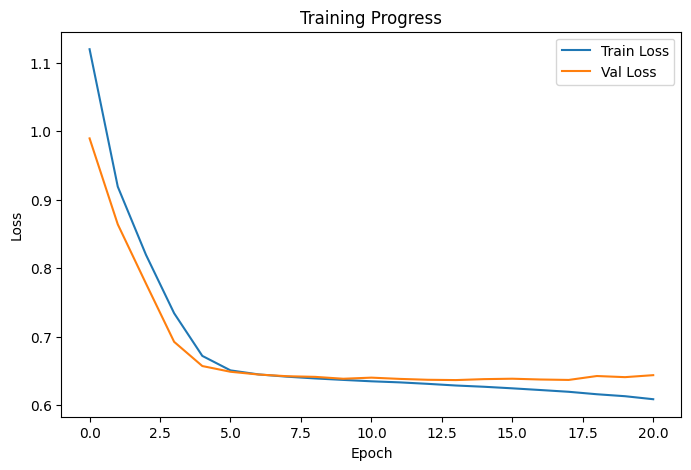

In [5]:
# cell c
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from pytorch_msssim import MS_SSIM
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import os

# ---- U-Net ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch), nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=2, padding=1)
        self.conv = ConvBlock(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.pre = nn.Conv2d(in_ch, in_ch * 4, kernel_size=3, padding=1)
        self.shuffle = nn.PixelShuffle(2)
        self.conv = ConvBlock(in_ch + skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.shuffle(self.pre(x))
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))

class BeamformingUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=48, depth=3):
        super().__init__()
        self.stem = ConvBlock(in_channels, base_channels)
        chs = [base_channels * (2 ** i) for i in range(depth + 1)]
        self.downs = nn.ModuleList([Down(chs[i], chs[i+1]) for i in range(depth)])
        self.ups = nn.ModuleList([Up(chs[i+1], chs[i], chs[i]) for i in reversed(range(depth))])
        self.head = nn.Conv2d(base_channels, out_channels, kernel_size=1)
        self.residual_gain = nn.Parameter(torch.tensor(0.1))
        self.input_proj = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        skips = []
        h = self.stem(x); skips.append(h)
        for down in self.downs:
            h = down(h); skips.append(h)
        h = skips.pop()
        for up in self.ups:
            skip = skips.pop(); h = up(h, skip)
        return torch.sigmoid(self.input_proj(x) + self.residual_gain * self.head(h))

# ---- Loss ----
class VGGPerceptualLoss(nn.Module):
    def __init__(self, layer_idx=16, resize=True):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features
        self.slice = nn.Sequential(*[vgg[i] for i in range(layer_idx)]).eval()
        for p in self.slice.parameters(): p.requires_grad = False
        self.resize = resize
        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std", torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def forward(self, pred, target):
        def prep(x):
            x = x.repeat(1,3,1,1)
            if self.resize and x.shape[-1] != 224:
                x = nn.functional.interpolate(x, size=(224,224), mode="bilinear", align_corners=False)
            return (x - self.mean) / self.std
        with torch.no_grad(): target_feat = self.slice(prep(target))
        return nn.functional.mse_loss(self.slice(prep(pred)), target_feat)

class CompositeUltrasoundLoss(nn.Module):
    def __init__(self, w_l1=1.0, w_msssim=1.0, w_perceptual=0.1, msssim_data_range=1.0, use_perceptual=True):
        super().__init__()
        self.w_l1, self.w_msssim, self.w_perceptual = w_l1, w_msssim, w_perceptual
        self.l1 = nn.L1Loss()
        self.msssim = MS_SSIM(data_range=msssim_data_range, size_average=True, channel=1, win_size=7)
        self.use_perceptual = use_perceptual
        if use_perceptual: self.perceptual = VGGPerceptualLoss()
    def forward(self, pred, target):
        l1_loss = self.l1(pred, target)
        msssim_loss = 1.0 - self.msssim(pred, target)
        total = self.w_l1*l1_loss + self.w_msssim*msssim_loss
        logs = {"l1": l1_loss.item(), "msssim_loss": msssim_loss.item()}
        if self.use_perceptual:
            perc_loss = self.perceptual(pred, target)
            total = total + self.w_perceptual*perc_loss
            logs["perceptual"] = perc_loss.item()
        logs["total"] = total.item()
        return total, logs

# ---- Training (bigger model + warmup + early stopping) ----
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = BeamformingUNet(in_channels=1, out_channels=1, base_channels=48, depth=3).to(device)
criterion = CompositeUltrasoundLoss().to(device)
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

EPOCHS = 50
WARMUP_EPOCHS = 3
PATIENCE = 7
MIN_DELTA = 1e-4

warmup = LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

train_losses, val_losses = [], []
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss, logs = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss, _ = criterion(pred, yb)
            epoch_val_loss += loss.item()
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    scheduler.step()

    marker = ""
    if avg_val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "/kaggle/working/model_best.pt")
        marker = "  <- NEW BEST"
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss={avg_train_loss:.4f}, "
          f"val_loss={avg_val_loss:.4f}, lr={scheduler.get_last_lr()[0]:.2e}, "
          f"no_improve={epochs_no_improve}{marker}")
    torch.save(model.state_dict(), "/kaggle/working/model_latest.pt")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

print(f"\nBest val_loss: {best_val_loss:.4f}")
print("model_best.pt exists:", os.path.exists("/kaggle/working/model_best.pt"))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Training Progress")
plt.savefig("/kaggle/working/training_curve.png", dpi=150)
plt.show()

In [6]:
def _delay_channels(phantom, rf_by_angle, angles_rad):
    cfg = phantom.cfg
    n_time = rf_by_angle.shape[-1]
    Xg, Zg = phantom.Xg, phantom.Zg
    H, W = Xg.shape
    n_elem = cfg.n_transducers
    delayed = np.zeros((len(angles_rad), n_elem, H, W), dtype=np.float32)
    for a_idx, angle in enumerate(angles_rad):
        t_tx = (Xg * np.sin(angle) + Zg * np.cos(angle)) / cfg.c
        ex = phantom.elem_x[:, None, None]
        r_rx = np.sqrt((Xg[None, :, :] - ex) ** 2 + Zg[None, :, :] ** 2)
        delay_samples = (t_tx[None, :, :] + r_rx / cfg.c) * cfg.fs
        idx = np.clip(delay_samples.astype(np.int64), 0, n_time - 1)
        flat_idx = idx.reshape(n_elem, -1)
        gathered = np.take_along_axis(rf_by_angle[a_idx], flat_idx, axis=1)
        delayed[a_idx] = gathered.reshape(n_elem, H, W)
    return delayed


def dmas_beamform_from_delayed(delayed):
    out = np.zeros(delayed.shape[-2:], dtype=np.float32)
    for a_idx in range(delayed.shape[0]):
        x = delayed[a_idx]
        signed_sqrt = np.sign(x) * np.sqrt(np.abs(x))
        s = signed_sqrt.sum(axis=0)
        out += 0.5 * (s ** 2 - (x ** 2).sum(axis=0))
    return out


def coherence_factor(delayed):
    n_elem = delayed.shape[1]
    cf_maps = []
    for a_idx in range(delayed.shape[0]):
        x = delayed[a_idx]
        numerator = (x.sum(axis=0)) ** 2
        denominator = n_elem * (x ** 2).sum(axis=0) + 1e-8
        cf_maps.append(numerator / denominator)
    return np.mean(cf_maps, axis=0)


def dmas_cf_beamform_from_delayed(delayed):
    return dmas_beamform_from_delayed(delayed) * coherence_factor(delayed)


def adaptive_depth_normalize(envelope, smooth_window=9):
    row_rms = np.sqrt(np.mean(envelope**2, axis=1) + 1e-12)
    kernel = np.ones(smooth_window) / smooth_window
    row_rms_smooth = np.convolve(row_rms, kernel, mode='same')
    target = np.median(row_rms_smooth)
    gain = target / (row_rms_smooth + 1e-12)
    return envelope * gain[:, None]


def to_log_compressed(image, dynamic_range_db=60.0):
    from scipy.signal import hilbert
    envelope = np.abs(hilbert(image, axis=0))
    envelope = adaptive_depth_normalize(envelope)
    log_img = 20 * np.log10(envelope / (envelope.max() + 1e-8) + 1e-8)
    log_img = np.clip(log_img, -dynamic_range_db, 0)
    return (log_img + dynamic_range_db) / dynamic_range_db

print("Cell C2 ready")

Cell C2 ready


DAS: PSNR=15.53 dB, SSIM=0.3448
DMAS+CF: PSNR=11.19 dB, SSIM=0.0414
DL Model: PSNR=15.68 dB, SSIM=0.3258


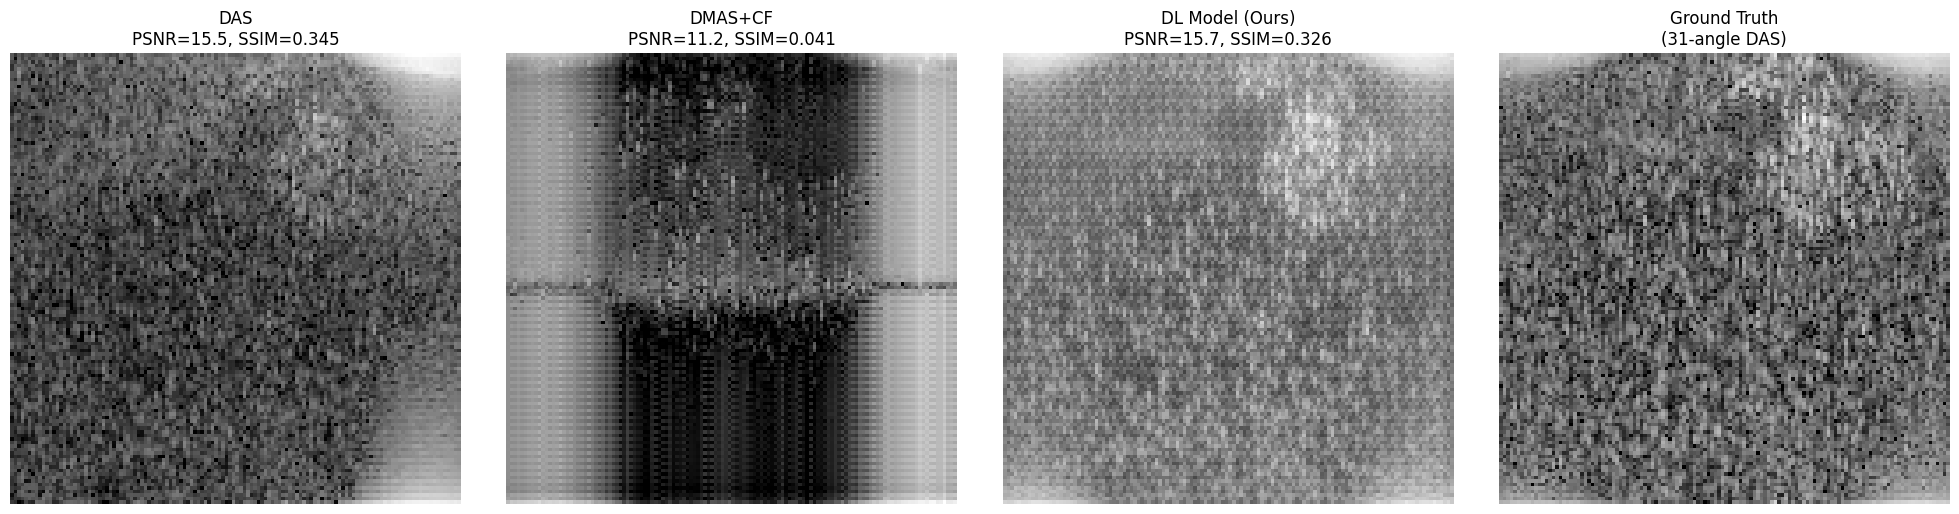

In [7]:
#cell D
from pytorch_msssim import ssim as ssim_fn

# ============================================================
# Ek bilkul NAYA phantom banate hain (train/val se alag seed
# range) — taake ye ek "fair test" ho.
# ============================================================
test_cfg = SimConfig(image_size=128, n_transducers=128, n_scatterers=6000,
                      seed=20_000_000, apply_tgc=True)
phantom = PointScattererPhantom(test_cfg)
sparse1_angles, full_angles = make_angle_sets(n_sparse=1, n_full=31, max_deg=20.0)
sparse5_angles, _ = make_angle_sets(n_sparse=5, n_full=31, max_deg=20.0)

input_img, target_img, rf_sparse1 = phantom.generate_pair(sparse1_angles, full_angles)
_, _, rf_sparse5 = phantom.generate_pair(sparse5_angles, full_angles)

das_img = input_img   # 1-angle DAS (already computed)

# DMAS+CF (5 angles)
angles_rad = np.deg2rad(sparse5_angles)
delayed = _delay_channels(phantom, rf_sparse5, angles_rad)
dmas_cf_img = to_log_compressed(dmas_cf_beamform_from_delayed(delayed))

# ============================================================
# Trained model load karo — base_channels=48 (FINAL model ka
# architecture, 32 NAHI, kyunki humne scale-up kiya tha)
# ============================================================
trained_model = BeamformingUNet(in_channels=1, out_channels=1, base_channels=48, depth=3).to(device)
trained_model.load_state_dict(torch.load("/kaggle/working/model_best.pt", map_location=device))
trained_model.eval()

with torch.no_grad():
    x = torch.from_numpy(input_img[None, None, :, :].astype(np.float32)).to(device)
    dl_pred = trained_model(x).squeeze().cpu().numpy()

# ============================================================
# Metrics
# ============================================================
def psnr_torch(pred, target, data_range=1.0):
    mse = torch.mean((pred - target) ** 2)
    return 10 * torch.log10(data_range ** 2 / mse) if mse > 1e-10 else torch.tensor(100.0)

target_t = torch.from_numpy(target_img[None, None].astype(np.float32))

results = {}
for name, img in [("DAS", das_img), ("DMAS+CF", dmas_cf_img), ("DL Model", dl_pred)]:
    img_t = torch.from_numpy(img[None, None].astype(np.float32))
    p = psnr_torch(img_t, target_t).item()
    s = ssim_fn(img_t, target_t, data_range=1.0).item()
    results[name] = (p, s)
    print(f"{name}: PSNR={p:.2f} dB, SSIM={s:.4f}")

# ============================================================
# Final figure
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(das_img, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"DAS\nPSNR={results['DAS'][0]:.1f}, SSIM={results['DAS'][1]:.3f}")
axes[1].imshow(dmas_cf_img, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"DMAS+CF\nPSNR={results['DMAS+CF'][0]:.1f}, SSIM={results['DMAS+CF'][1]:.3f}")
axes[2].imshow(dl_pred, cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"DL Model (Ours)\nPSNR={results['DL Model'][0]:.1f}, SSIM={results['DL Model'][1]:.3f}")
axes[3].imshow(target_img, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Ground Truth\n(31-angle DAS)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/final_comparison.png", dpi=150)
plt.show()

  5/25 phantoms evaluated (23.3s)
  10/25 phantoms evaluated (46.5s)
  15/25 phantoms evaluated (70.1s)
  20/25 phantoms evaluated (93.5s)
  25/25 phantoms evaluated (116.8s)

Total time: 116.8s

FINAL RESULTS (mean +/- std over 25 held-out phantoms)
DAS       : PSNR = 13.26 +/- 1.09 dB   SSIM = 0.3268 +/- 0.0132
DMAS+CF   : PSNR = 10.98 +/- 1.06 dB   SSIM = 0.0456 +/- 0.0066
DL Model  : PSNR = 17.56 +/- 0.73 dB   SSIM = 0.3407 +/- 0.0150


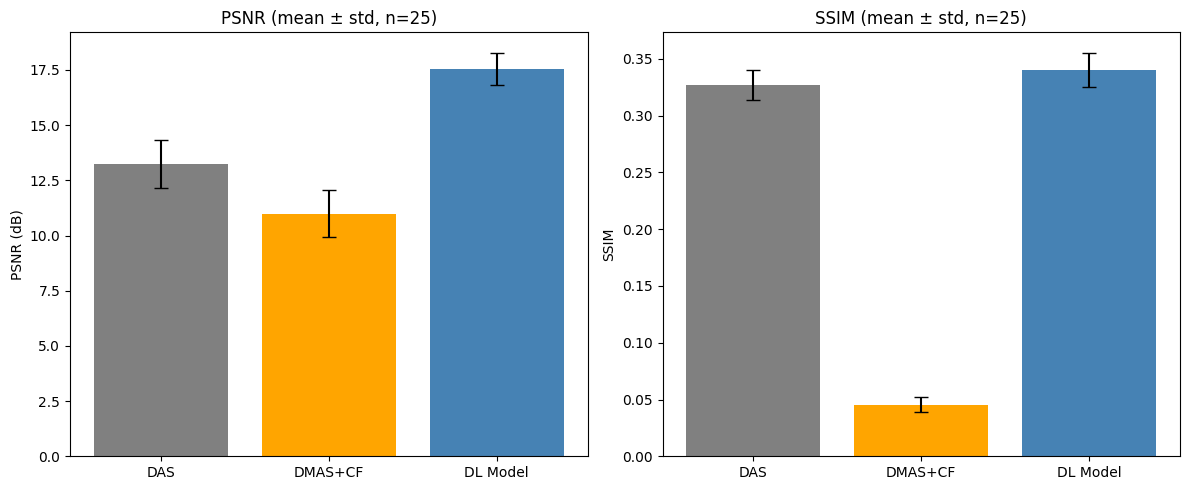

In [8]:
#cell E
import time

# ============================================================
# 25 alag test phantoms pe evaluate karte hain — train/val/
# single-test se disjoint seed range (30,000,000+), taake
# result statistically meaningful ho, sirf ek "lucky example"
# na ho.
# ============================================================
N_TEST = 25
TEST_SEED_OFFSET = 30_000_000

sparse1_angles, full_angles = make_angle_sets(1, 31, 20.0)
sparse5_angles, _ = make_angle_sets(5, 31, 20.0)

all_results = {"DAS": {"psnr": [], "ssim": []},
               "DMAS+CF": {"psnr": [], "ssim": []},
               "DL Model": {"psnr": [], "ssim": []}}

t0 = time.time()
for i in range(N_TEST):
    cfg_i = SimConfig(image_size=128, n_transducers=128, n_scatterers=6000,
                       seed=TEST_SEED_OFFSET + i, apply_tgc=True)
    phantom = PointScattererPhantom(cfg_i)

    input_img, target_img, rf_sparse1_i = phantom.generate_pair(sparse1_angles, full_angles)
    _, _, rf_sparse5_i = phantom.generate_pair(sparse5_angles, full_angles)

    das_img = input_img
    angles_rad = np.deg2rad(sparse5_angles)
    delayed = _delay_channels(phantom, rf_sparse5_i, angles_rad)
    dmas_cf_img = to_log_compressed(dmas_cf_beamform_from_delayed(delayed))

    with torch.no_grad():
        x = torch.from_numpy(input_img[None, None].astype(np.float32)).to(device)
        dl_pred = trained_model(x).squeeze().cpu().numpy()

    target_t = torch.from_numpy(target_img[None, None].astype(np.float32))
    for name, img in [("DAS", das_img), ("DMAS+CF", dmas_cf_img), ("DL Model", dl_pred)]:
        img_t = torch.from_numpy(img[None, None].astype(np.float32))
        p = psnr_torch(img_t, target_t).item()
        s = ssim_fn(img_t, target_t, data_range=1.0).item()
        all_results[name]["psnr"].append(p)
        all_results[name]["ssim"].append(s)

    if (i + 1) % 5 == 0:
        print(f"  {i+1}/{N_TEST} phantoms evaluated ({time.time()-t0:.1f}s)")

print(f"\nTotal time: {time.time()-t0:.1f}s\n")
print("=" * 55)
print("FINAL RESULTS (mean +/- std over", N_TEST, "held-out phantoms)")
print("=" * 55)
summary = {}
for name, vals in all_results.items():
    p_mean, p_std = np.mean(vals["psnr"]), np.std(vals["psnr"])
    s_mean, s_std = np.mean(vals["ssim"]), np.std(vals["ssim"])
    summary[name] = (p_mean, p_std, s_mean, s_std)
    print(f"{name:10s}: PSNR = {p_mean:5.2f} +/- {p_std:.2f} dB   SSIM = {s_mean:.4f} +/- {s_std:.4f}")

# ---- Bar chart with error bars ----
methods = list(summary.keys())
psnr_means = [summary[m][0] for m in methods]
psnr_stds = [summary[m][1] for m in methods]
ssim_means = [summary[m][2] for m in methods]
ssim_stds = [summary[m][3] for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(methods, psnr_means, yerr=psnr_stds, capsize=5, color=["gray", "orange", "steelblue"])
axes[0].set_ylabel("PSNR (dB)"); axes[0].set_title(f"PSNR (mean ± std, n={N_TEST})")
axes[1].bar(methods, ssim_means, yerr=ssim_stds, capsize=5, color=["gray", "orange", "steelblue"])
axes[1].set_ylabel("SSIM"); axes[1].set_title(f"SSIM (mean ± std, n={N_TEST})")
plt.tight_layout()
plt.savefig("/kaggle/working/final_metrics_summary.png", dpi=150)
plt.show()

In [9]:
#cell f
# ============================================================
# Model ko DIFFERENT physics settings pe test karte hain (jo
# training mein nahi dekhi) — taake pata chale kya ye sirf
# training distribution "yaad" kar raha hai ya physics samajh
# raha hai.
# ============================================================
N_GEN_TEST = 15

def evaluate_condition(label, attenuation, n_scatterers, seed_offset):
    psnrs, ssims = [], []
    for i in range(N_GEN_TEST):
        cfg_i = SimConfig(image_size=128, n_transducers=128, n_scatterers=n_scatterers,
                           attenuation_db_cm_mhz=attenuation, seed=seed_offset + i, apply_tgc=True)
        phantom = PointScattererPhantom(cfg_i)
        input_img, target_img, _ = phantom.generate_pair(sparse1_angles, full_angles)
        with torch.no_grad():
            x = torch.from_numpy(input_img[None, None].astype(np.float32)).to(device)
            pred = trained_model(x).squeeze().cpu().numpy()
        pred_t = torch.from_numpy(pred[None, None].astype(np.float32))
        target_t = torch.from_numpy(target_img[None, None].astype(np.float32))
        psnrs.append(psnr_torch(pred_t, target_t).item())
        ssims.append(ssim_fn(pred_t, target_t, data_range=1.0).item())
    p_mean, p_std = np.mean(psnrs), np.std(psnrs)
    s_mean, s_std = np.mean(ssims), np.std(ssims)
    print(f"{label}: PSNR={p_mean:.2f}+/-{p_std:.2f} dB, SSIM={s_mean:.4f}+/-{s_std:.4f}")
    return p_mean, s_mean

print("=" * 60)
print("GENERALIZATION CHECK — different physics than training")
print("=" * 60)
p_indist, s_indist = evaluate_condition("In-distribution (attn=0.5, n_scat=6000)", 0.5, 6000, 30_000_000)
p_attn, s_attn = evaluate_condition("Shifted attenuation (attn=0.8)", 0.8, 6000, 40_000_000)
p_dens, s_dens = evaluate_condition("Shifted density (n_scat=3000)", 0.5, 3000, 50_000_000)

print(f"\nPSNR drop (attenuation shift): {p_indist - p_attn:.2f} dB")
print(f"PSNR drop (density shift):     {p_indist - p_dens:.2f} dB")
print("\n(Chota drop = achi generalization. Bara drop = model 'overfit to exact simulator settings')")

GENERALIZATION CHECK — different physics than training
In-distribution (attn=0.5, n_scat=6000): PSNR=17.61+/-0.53 dB, SSIM=0.3417+/-0.0127
Shifted attenuation (attn=0.8): PSNR=17.49+/-0.55 dB, SSIM=0.3456+/-0.0122
Shifted density (n_scat=3000): PSNR=17.00+/-0.38 dB, SSIM=0.3553+/-0.0126

PSNR drop (attenuation shift): 0.12 dB
PSNR drop (density shift):     0.61 dB

(Chota drop = achi generalization. Bara drop = model 'overfit to exact simulator settings')
